
# Exploratory Data Analysis & Data Preparation :-
## Objectives :-
* Load and explore the resume dataset
* Perform comprehensive EDA
* Assess data quality
* Clean and prepare data for modeling

In [23]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns     # Seaborn is a visualization library built on top of Matplotlib.
import warnings
warnings.filterwarnings('ignore')
# Here it Prevents warning messages from cluttering your output.
# Warnings are not errors, but they can be noisy (e.g., deprecation notices).
# By ignoring them, your plots and results look cleaner in notebooks or scripts.

# Set visualization style
sns.set_style('whitegrid')
# set_style('whitegrid') applies a theme with: White background & Light gray grid lines
# This makes plots easier to read, especially for comparisons or statistical charts.

plt.rcParams['figure.figsize'] = (12, 6)
# rcParams is Matplotlib’s runtime configuration dictionary.
# figure.figsize sets the default size of all plots:
# Width = 12 inches
# Height = 6 inches
# This ensures consistent, larger plots without needing to specify size each time.

print("Libraries imported successfully!")


Libraries imported successfully!


In [24]:
# Load dataset
# Pandas can use different parsers (“engines”) to read CSV files:
# C engine → faster, written in C, but less flexible.
# Python engine → slower, but more tolerant of irregular formatting.
# Here, the Python engine is chosen, probably because the CSV has messy or inconsistent rows.
df = pd.read_csv('resumeJD2_pairs.csv', engine='python', on_bad_lines='skip')
# Tells Pandas what to do if a row in the CSV is malformed (e.g., wrong number of columns).
# Options:
# 'error' → raise an error (default).
# 'warn' → print a warning and skip the bad line.
# 'skip' → silently skip bad lines

print(f"Data Loaded Successfully: {df.shape[0]} rows, {df.shape[1]} columns")

print(f"\nColumns: {list(df.columns)}")


Data Loaded Successfully: 500 rows, 4 columns

Columns: ['resume_text', 'job_description', 'match_score', 'match_label']


In [25]:
# First Look at the data
print("First 5 rows: ")
df.head()


First 5 rows: 


,resume_text,job_description,match_score,match_label
0,Name: Kritika Shah || Email: kritika.shah55@gm...,Job Title: FP&A Analyst || Company: Amazon | L...,0.55,partial match
1,Name: Arjun Verma || Email: arjun.verma70@gmai...,Job Title: Design Lead || Company: Paytm | Loc...,0.27,no match
2,Name: Manish Bhatt || Email: manish.bhatt89@gm...,Job Title: Security Analyst || Company: KPMG |...,0.46,partial match
3,Name: Natasha Sharma || Email: natasha.sharma7...,Job Title: Sales Director || Company: Ola | Lo...,0.09,no match
4,Name: Kavya Agarwal || Email: kavya.agarwal75@...,Job Title: Business Development Manager || Com...,0.66,partial match


In [26]:
# dataset Information :-
print("Dataset Info: ")
print("=" * 60)

df.info()


Dataset Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resume_text      500 non-null    object 
 1   job_description  500 non-null    object 
 2   match_score      500 non-null    float64
 3   match_label      500 non-null    object 
dtypes: float64(1), object(3)
memory usage: 15.8+ KB


In [27]:
# statistical summary :-
print("\nStatistical Summary: ")

df.describe()



Statistical Summary: 


,match_score
count,500.000000
mean,0.529720
std,0.283882
min,0.050000
25%,0.280000
50%,0.540000
75%,0.790000
max,0.980000


In [28]:
# text columns summary
print("\nText Columns Summary: ")

df.describe(include='object')
# This line is asking Pandas to summarize the non‑numeric (categorical/text) columns in your DataFrame



Text Columns Summary: 


,resume_text,job_description,match_label
count,500,500,500
unique,500,500,3
top,Name: Shreya Saxena || Email: shreya.saxena63@...,Job Title: Credit Analyst || Company: CRED | L...,no match
freq,1,1,190


In [29]:
# Check for the missing values

print("Missing Values Analysis:- ")
print("=" * 60)

missing = df.isnull().sum()

missing

Missing Values Analysis:- 


,0
resume_text,0
job_description,0
match_score,0
match_label,0


In [30]:
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_percent
})

print(missing_df)
print(f"\nTotal missing values: {missing.sum()}")


                 Missing Count  Percentage
resume_text                  0         0.0
job_description              0         0.0
match_score                  0         0.0
match_label                  0         0.0

Total missing values: 0


In [31]:
full_dupes = df.duplicated().sum()

print(f"Full Duplicate Rows: {full_dupes}")
# Here we are checking duplicate values because if they exists then they can cause bias during BERT model training using this dataset


Full Duplicate Rows: 0


In [32]:
# This only consider duplicates where both the resume text and the job description are identical.
pair_dupes = df.duplicated(subset=['resume_text', 'job_description']).sum()

print(f"Duplicate resume + JD pairs: {pair_dupes}")


Duplicate resume + JD pairs: 0


In [33]:
print("\nDuplicate rows: ")
df[df.duplicated(subset=['resume_text', 'job_description'], keep=False)]
# Here keep=False → marks all duplicates as True, not just the later ones.
#Example: If two identical rows exist, both will be flagged as duplicates.




Duplicate rows: 


,resume_text,job_description,match_score,match_label


In [34]:
df.nunique()

,0
resume_text,500
job_description,500
match_score,93
match_label,3


In [37]:
df['match_label'].unique()

array(['partial match', 'no match', 'match'], dtype=object)

In [35]:
# ------- Section: Uniqueness Checks ----------------------------------------------------------------

print(f"Total rows: {len(df)}")
print(f"Unique resumes: {df['resume_text'].nunique()}")
print(f"Unique JDs: {df['job_description'].nunique()}")
print(f"Unique resume + JD pairs: {df[['resume_text','job_description']].drop_duplicates().shape[0]}")


Total rows: 500
Unique resumes: 500
Unique JDs: 500
Unique resume + JD pairs: 500


In [38]:
# ------- Section: Label Consistency ----------------------------------------------------------------

# What labels exists? (spot the case inconsistency!)
print("Unique labels found: ")
print(df['match_label'].value_counts())

# Is the casing consistent?
print(f"\nExpected 3 labels, got: {df['match_label'].nunique()} unique values")
print("Distinct values:", df['match_label'].unique())



Unique labels found: 
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64

Expected 3 labels, got: 3 unique values
Distinct values: ['partial match' 'no match' 'match']


In [39]:

print("Score distribution:")
print(df['match_score'].describe())
print()

# Scores must be between 0.0 and 1.0 — flag the bad ones
# Because cosine similarity also have range between 0 to 1 only
invalid_scores = df[(df['match_score'] < 0) | (df['match_score'] > 1)]
# Filters the DataFrame, returning only rows that meet the condition.
# These rows are stored in invalid_scores.

# len(invalid_scores) :- Counts how many invalid rows exist.
print(f"Invalid scores (out of 0–1 range): {len(invalid_scores)}")

print(invalid_scores[['match_label', 'match_score']])


Score distribution:
count    500.000000
mean       0.529720
std        0.283882
min        0.050000
25%        0.280000
50%        0.540000
75%        0.790000
max        0.980000
Name: match_score, dtype: float64

Invalid scores (out of 0–1 range): 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []


In [53]:
# ----------------- Section: Label vs Score Sanity Check ---------------------------------

# Do scores actually match what the label says?

print("Score stats per label (after lowercasing): ")

# .str.lower() :- Applies the string method .lower() to every entry in the column. Converts all text to lowercase.
# Example: "Match" → "match", "NoMatch" → "nomatch".
df['match_label_lower'] = df['match_label'].str.lower()

print(df.groupby('match_label_lower')['match_score'].describe().round(2))

# Expected:
#   high label i.e match  → 0.75 – 0.95
#   medium label i.e partial match  → 0.40 – 0.70
#   low label i.e no match   → 0.05 – 0.35


Score stats per label (after lowercasing): 
                   count  mean   std   min   25%   50%   75%   max
match_label_lower                                                 
match              158.0  0.86  0.07  0.75  0.80  0.86  0.93  0.98
no match           190.0  0.22  0.10  0.05  0.13  0.22  0.31  0.39
partial match      152.0  0.57  0.10  0.40  0.48  0.58  0.67  0.74


In [54]:
df.groupby('match_label_lower')['match_score'].mean()

,match_score
match_label_lower,
match,0.860570
no match,0.220000
partial match,0.572961


In [55]:
df.isnull()

,resume_text,job_description,match_score,match_label,match_label_lower
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
495,False,False,False,False,False
496,False,False,False,False,False
497,False,False,False,False,False
498,False,False,False,False,False


In [56]:
# ----------------- Section: Null values ---------------------------------

print("Missing values per column:")
print(df.isnull().sum())
print()

# Show the rows with nulls
# This line is used to filter out all rows in your DataFrame that contain at least one missing value (NaN)
nulls = df[df.isnull().any(axis=1)]
# .any(axis=1) :- Checks across each row (axis=1 means row‑wise).
# Returns True if any column in that row has a missing value.Returns False if the row is fully complete.

print(f"Rows with at least one null: {len(nulls)}")
nulls[['match_label', 'match_score']].head(10)



Missing values per column:
resume_text          0
job_description      0
match_score          0
match_label          0
match_label_lower    0
dtype: int64

Rows with at least one null: 0


,match_label,match_score


In [57]:
# ----------------- Summary: All issues found ---------------------------------

print("=" * 50)
print("DATA QUALITY REPORT — resumeJD2_pairs.csv")
print("=" * 50)
print(f"Total rows:             {len(df)}")
print(f"Full duplicates:        {df.duplicated().sum()}")
print(f"Duplicate pairs:        {df.duplicated(subset=['resume_text','job_description']).sum()}")
print(f"Null resume_text:       {df['resume_text'].isnull().sum()}")
print(f"Null job_description:   {df['job_description'].isnull().sum()}")
print(f"Label case variants:    {df['match_label'].nunique()} (expected 3)")
print(f"Invalid scores (<0 or >1): {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")
print("=" * 50)


DATA QUALITY REPORT — resumeJD2_pairs.csv
Total rows:             500
Full duplicates:        0
Duplicate pairs:        0
Null resume_text:       0
Null job_description:   0
Label case variants:    3 (expected 3)
Invalid scores (<0 or >1): 0


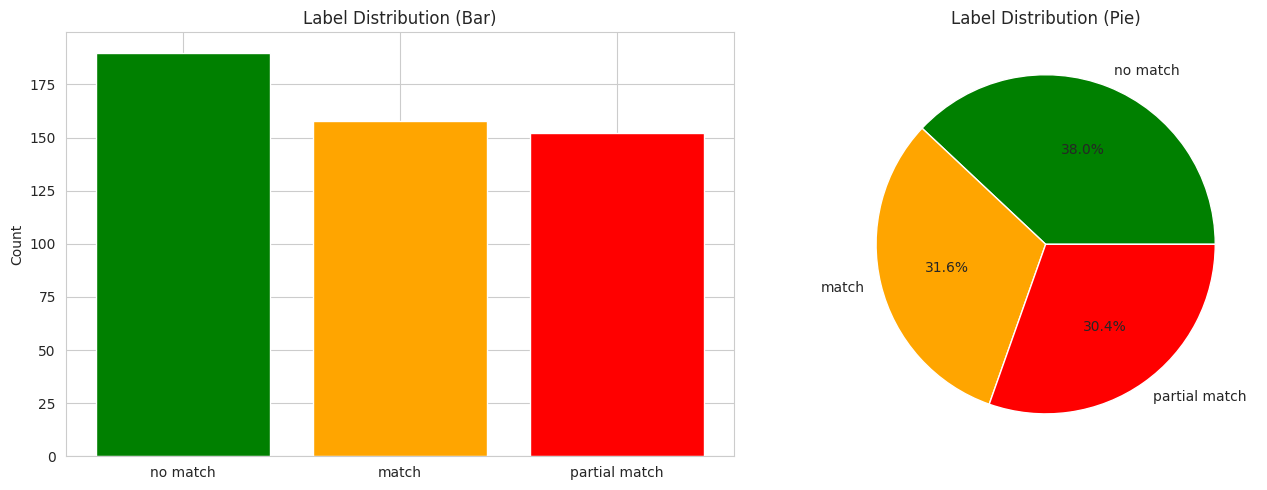

In [58]:
# Pie chart +  bar chart side by side

# Here we are creating Matplotlib figure with multiple subplots (axes):
# A figure object (fig) → the overall canvas.
# One or more axes objects (axes) → the individual plotting areas inside the figure.
# (1, 2) :- Defines the layout: 1 row, 2 columns. So you get two side‑by‑side plots.
# axes will be a NumPy array of length 2, holding references to each subplot.
# figsize=(14, 5) :- Sets the overall figure size in inches: Width = 14 inches & Height = 5 inches
# This makes the plots wide and not too tall, good for comparisons.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# fig → the container for everything (title, subplots, legends, etc.).
# axes → an array of two subplot objects, e.g. axes[0] and axes[1].

counts = df['match_label'].str.lower().value_counts()

axes[0].bar(counts.index, counts.values, color=['green','orange','red'])
axes[0].set_title('Label Distribution (Bar)')
axes[0].set_ylabel('Count')

# autopct stands for “automatic percentage”. It tells Matplotlib how to display the percentage values inside the pie slices.
# '%1.1f%%' is a Python format string: % → placeholder for a value. And 1.1f → format as a floating‑point number with 1 digit before the decimal and 1 digit after. Example: 25.0, 33.3, 12.5.
# %% → prints a literal percent sign (%).
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['green','orange','red'])
axes[1].set_title('Label Distribution (Pie)')

plt.tight_layout()
plt.show()


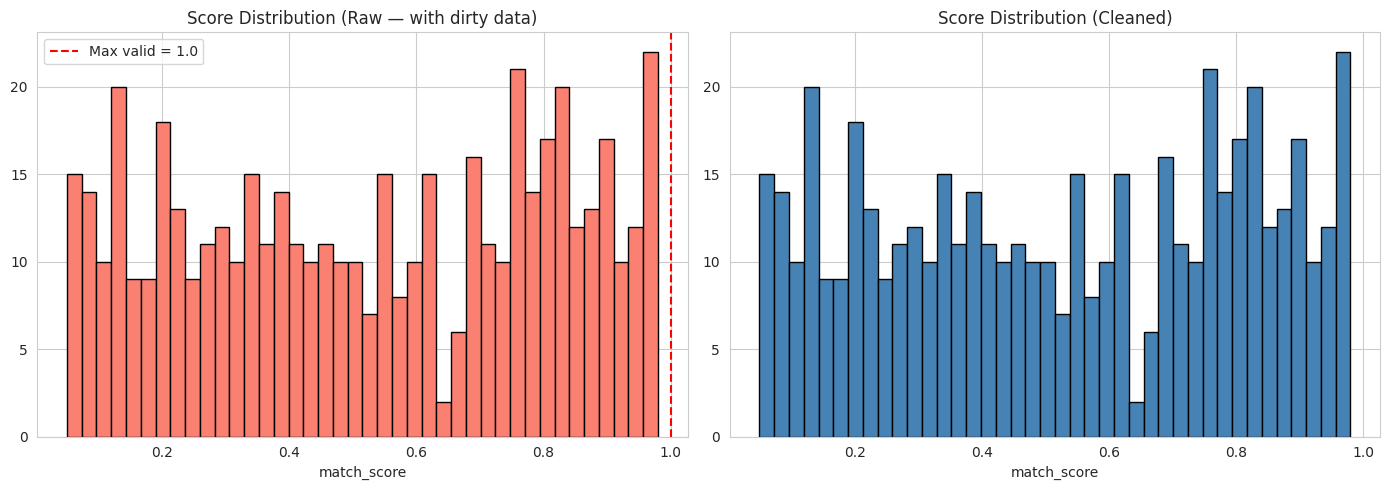

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before cleaning
axes[0].hist(df['match_score'], bins=40, color='salmon', edgecolor='black')
axes[0].set_title('Score Distribution (Raw — with dirty data)')
axes[0].set_xlabel('match_score')

# axvline = axis vertical line. Draws a vertical line at x = 1.0 across the entire height of the plot. Useful for marking thresholds, limits, or reference points.
axes[0].axvline(1.0, color='red', linestyle='--', label='Max valid = 1.0')
axes[0].legend()

# After cleaning
clean = df[(df['match_score'] >= 0) & (df['match_score'] <= 1)]
axes[1].hist(clean['match_score'], bins=40, color='steelblue', edgecolor='black')
axes[1].set_title('Score Distribution (Cleaned)')
axes[1].set_xlabel('match_score')

plt.tight_layout()
plt.show()

# here we are getting almost similar result because our raw data is also very cleaned data


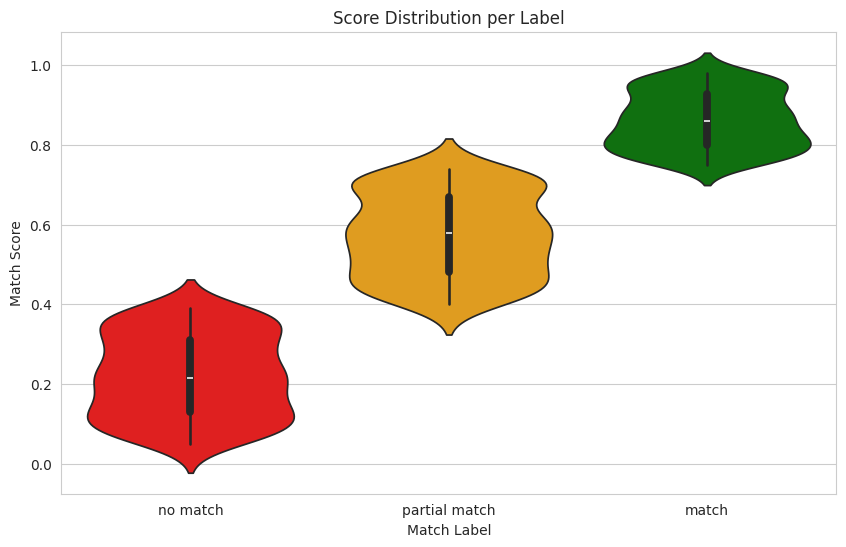

In [62]:
import seaborn as sns

df_plot = df.copy() # here we are creating the copy of this df

df_plot['match_label'] = df_plot['match_label'].str.lower()

df_plot = df_plot[(df_plot['match_score'] >= 0) & (df_plot['match_score'] <= 1)]

plt.figure(figsize=(10, 6))    # creating a figure or canvas of this size

# Draws a violin plot, which shows the distribution of data across categories. It’s like a combination of a boxplot and a kernel density plot:
# The “violin” shape shows the distribution (density).
# The white dot = median.
# Thick bar = interquartile range.
# Thin line = data range.
# order=['no match','partial match','match'] :- Ensures the categories appear in this specific order on the x‑axis. Without this, Seaborn might order them alphabetically.
# palette=['red','orange','green'] :- Assigns colors to the violins: no match → red, partial match → orange and match → green
sns.violinplot(data=df_plot, x='match_label', y='match_score', order=['no match','partial match','match'], palette=['red','orange','green'])

plt.title('Score Distribution per Label')
plt.xlabel('Match Label')
plt.ylabel('Match Score')
plt.show()


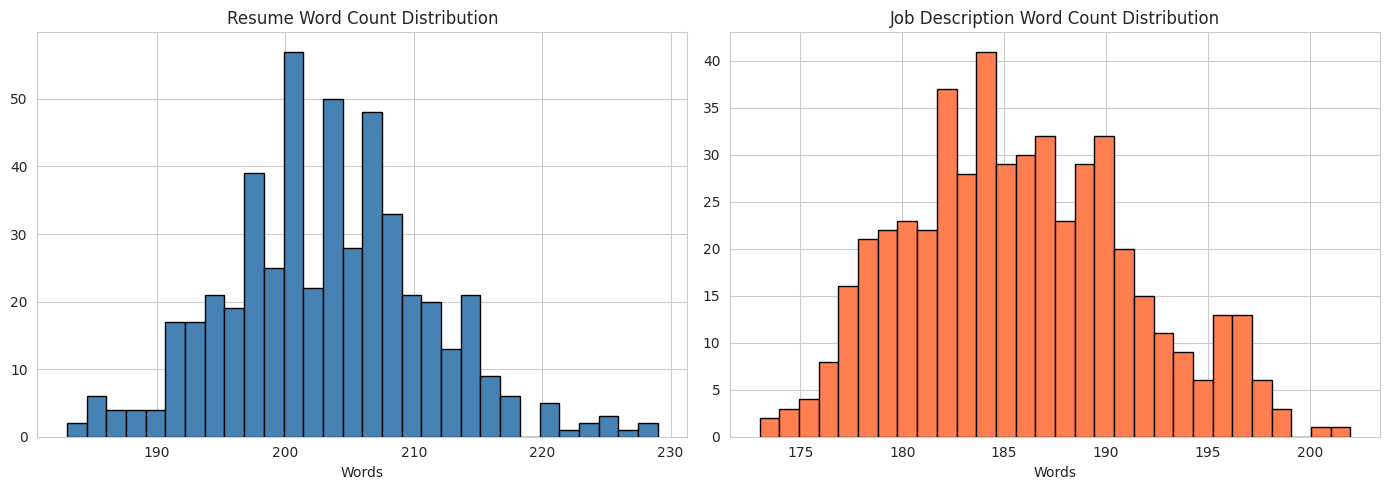

In [63]:
# .str.split() :- Splits each string into a list of words (default split = whitespace).
# Example: "Data Scientist Resume" → ["Data", "Scientist", "Resume"].
# .str.len() :- Counts the length of each list (i.e., number of words).
# Example: ["Data", "Scientist", "Resume"] → 3.
df_plot['resume_len'] = df_plot['resume_text'].str.split().str.len()
df_plot['jd_len'] = df_plot['job_description'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['resume_len'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Resume Word Count Distribution')
axes[0].set_xlabel('Words')

axes[1].hist(df_plot['jd_len'], bins=30, color='coral', edgecolor='black')
axes[1].set_title('Job Description Word Count Distribution')
axes[1].set_xlabel('Words')

plt.tight_layout()
plt.show()


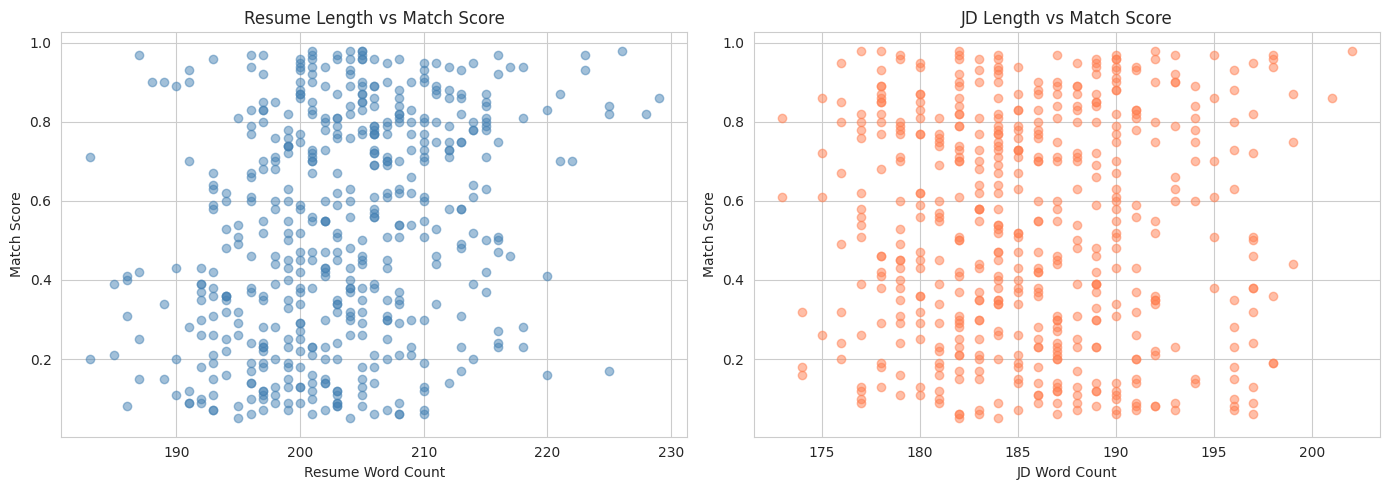

Resume length correlation: 0.286
JD length correlation:     0.001


In [64]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# alpha=0.5 :- Sets transparency of the points (50%).
axes[0].scatter(df_plot['resume_len'], df_plot['match_score'], alpha=0.5, color='steelblue')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Match Score')
axes[0].set_title('Resume Length vs Match Score')

axes[1].scatter(df_plot['jd_len'], df_plot['match_score'], alpha=0.5, color='coral')
axes[1].set_xlabel('JD Word Count')
axes[1].set_ylabel('Match Score')
axes[1].set_title('JD Length vs Match Score')

plt.tight_layout()
plt.show()

# Actual correlation values
# df_plot['resume_len'].corr(df_plot['match_score']) :- Computes the Pearson correlation coefficient between resume word counts (resume_len) and match scores (match_score).
# Value ranges from:
# +1 → strong positive correlation (longer resumes → higher scores).
# -1 → strong negative correlation (longer resumes → lower scores).
# 0 → no linear relationship.
# And then Rounds the correlation value to 3 decimal places for cleaner output.
print("Resume length correlation:", df_plot['resume_len'].corr(df_plot['match_score']).round(3))
print("JD length correlation:    ", df_plot['jd_len'].corr(df_plot['match_score']).round(3))



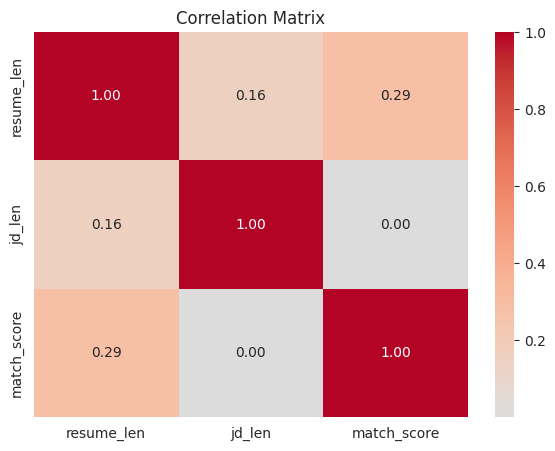

In [65]:
# Creating heatmap :-

plt.figure(figsize=(7, 5))

# Selects only the columns resume_len, jd_len, and match_score.
# .corr() computes the correlation matrix (default = Pearson correlation).
# Result: a 3×3 matrix showing correlation values between each pair of variables.
corr = df_plot[['resume_len', 'jd_len', 'match_score']].corr()

# center=0 → centers the colormap at 0, so correlations below 0 are bluish and above 0 are reddish.
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)

plt.title('Correlation Matrix')
plt.show()


## We will use WordCloud here :-

A word cloud is a visual representation of text where the size of each word reflects how frequently it appears in the source material. It’s commonly used in text analysis, presentations, and creative projects to highlight key themes or recurring words.

So Words that occur more often appear larger.

In [67]:
!pip install wordcloud

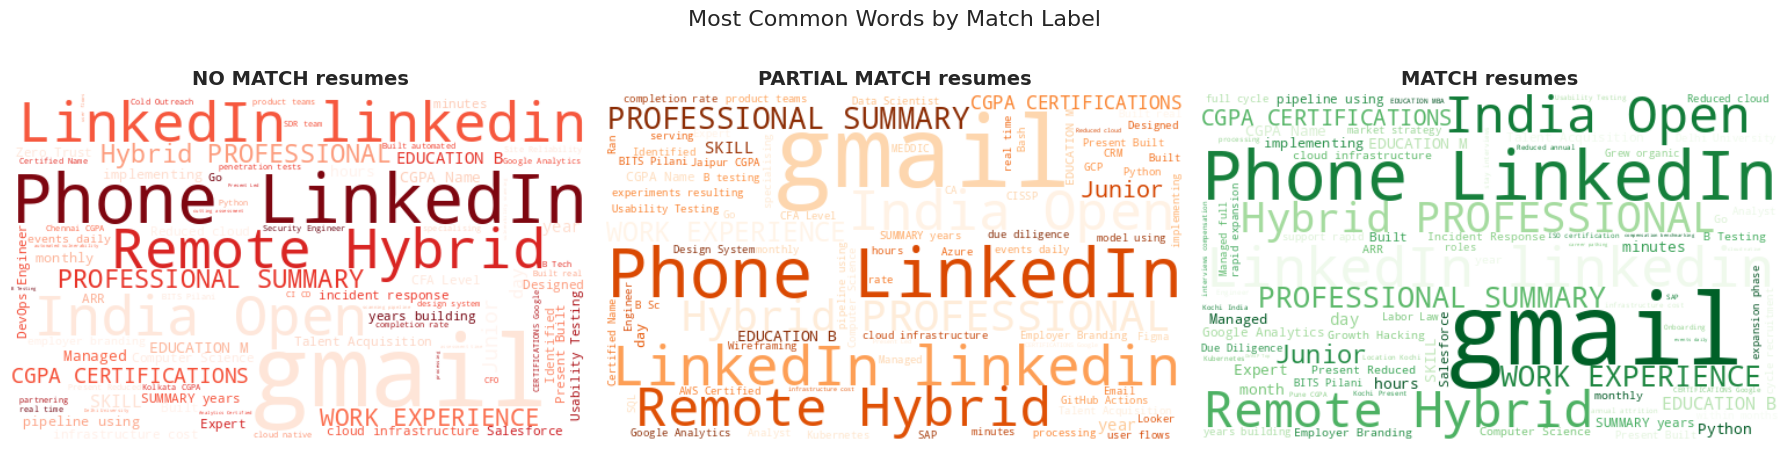

In [69]:
# Imports the WordCloud class from the wordcloud library, used to generate word clouds.
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels  = ['no match', 'partial match', 'match']
colors  = ['Reds', 'Oranges', 'Greens']

for ax, label, cmap in zip(axes, labels, colors):
    # Filters resumes belonging to the current category (match_label == label). Drops missing values (dropna()). Joins all resume texts into one big string. This combined text is the input for the word cloud.
    text = ' '.join(df_plot[df_plot['match_label'] == label]['resume_text'].dropna())

    # Creates a word cloud object with: width=500, height=300 → size of the cloud. background_color='white' → white background. colormap=cmap → color scheme (red/orange/green depending on category). max_words=80 → only the top 80 most frequent words are shown.
    # .generate(text) builds the word cloud from the combined resume text.
    wc = WordCloud(width=500, height=300, background_color='white', colormap=cmap, max_words=80).generate(text)

    # Displays the word cloud image on the subplot. interpolation='bilinear' smooths the rendering.
    ax.imshow(wc, interpolation='bilinear')

    ax.axis('off')
    ax.set_title(f'{label.upper()} resumes', fontsize=14, fontweight='bold')

plt.suptitle('Most Common Words by Match Label', fontsize=16)
plt.tight_layout()
plt.show()


In [70]:
# Always record the starting point so that you can see what changed

print("BEFORE CLEANING")
print("=" * 40)
print(f"Total rows:       {len(df)}")
print(f"Null resume_text: {df['resume_text'].isnull().sum()}")
print(f"Null job_desc:    {df['job_description'].isnull().sum()}")
print(f"Duplicates:       {df.duplicated().sum()}")
print(f"Label variants:   {df['match_label'].nunique()}")
print(f"Invalid scores:   {((df['match_score'] < 0) | (df['match_score'] > 1)).sum()}")

df_clean = df.copy()


BEFORE CLEANING
Total rows:       500
Null resume_text: 0
Null job_desc:    0
Duplicates:       0
Label variants:   3
Invalid scores:   0


In [71]:
# Problem: 'Match', 'match' can be treated as 2 different categories

print("Before:", df_clean['match_label'].value_counts().to_dict())

df_clean['match_label'] = df_clean['match_label'].str.lower().str.strip()

print("After: ", df_clean['match_label'].value_counts().to_dict())

print(f"\nUnique labels now: {df_clean['match_label'].nunique()} (expected 3)")


Before: {'no match': 190, 'match': 158, 'partial match': 152}
After:  {'no match': 190, 'match': 158, 'partial match': 152}

Unique labels now: 3 (expected 3)


In [72]:

print(f"Before dropping nulls: {len(df_clean)} rows")

# dropna(...) :- Removes rows that contain NaN (missing values).
# subset=['resume_text', 'job_description'] :- Restricts the check to only these two columns.
# A row will be dropped if either resume_text or job_description is missing.
# Other columns can still have NaN values — they won’t trigger removal.
df_clean = df_clean.dropna(subset=['resume_text', 'job_description'])

print(f"After dropping nulls:  {len(df_clean)} rows")
print(f"Removed: {len(df) - len(df_clean)} rows")


Before dropping nulls: 500 rows
After dropping nulls:  500 rows
Removed: 0 rows


In [73]:
print(f"Before removing duplicates: {len(df_clean)} rows")
print(f"Duplicate pairs found: {df_clean.duplicated(subset=['resume_text','job_description']).sum()}")

# A row is considered a duplicate if both the resume_text and job_description are identical to another row.
# Keeps the first occurrence of each duplicate pair. Later duplicates are dropped.
df_clean = df_clean.drop_duplicates(subset=['resume_text', 'job_description'], keep='first')

print(f"After removing duplicates:  {len(df_clean)} rows")


Before removing duplicates: 500 rows
Duplicate pairs found: 0
After removing duplicates:  500 rows


In [74]:

# Scores must be in [0.0, 1.0], anything else is a data error
# df_clean['match_score'] < 0.0 :- Produces a Boolean Series (True/False) for rows where match_score is less than 0.
#  invalid_mask:- A Boolean Series the same length as your DataFrame.
# Each entry is: True → invalid score (outside 0–1 range). False → valid score (within 0–1 range).
# invalid_mask is a Boolean Series (True for invalid rows, False otherwise).
invalid_mask = (df_clean['match_score'] < 0.0) | (df_clean['match_score'] > 1.0)

# Here .sum() counts how many True values exist → the number of invalid scores. Prints that count in a readable message.
print(f"Invalid scores found: {invalid_mask.sum()}")

# Filters the DataFrame to only rows where invalid_mask == True.
# Selects just the match_label and match_score columns for display.
# Shows which rows had invalid scores and their labels.
print(df_clean[invalid_mask][['match_label','match_score']])

df_clean = df_clean[~invalid_mask]
print(f"\nRows after removing invalid scores: {len(df_clean)}")


Invalid scores found: 0
Empty DataFrame
Columns: [match_label, match_score]
Index: []

Rows after removing invalid scores: 500


In [75]:

# Are the scores consistent with what the label claims?
# Expected: no match = 0.05 - 0.35, partial match = 0.40 - 0.70, match = 0.75 - 0.95

print("Score range per label:")
print(df_clean.groupby('match_label')['match_score'].agg(['min','max','mean']).round(2))

# Flag any rows where label and score contradict each other
def label_score_mismatch(row):
    score = row['match_score']
    label = row['match_label']
    if label == 'match' and score < 0.70:
      return True
    if label == 'partial match' and (score < 0.35 or score > 0.75):
      return True
    if label == 'no match' and score > 0.40:
      return True

    return False

# Applies the function to each row of the DataFrame. Returns a Boolean Series (True for mismatch, False otherwise). Stored in mismatches.
mismatches = df_clean.apply(label_score_mismatch, axis=1)

# Counts how many mismatches were found (since True = 1, False = 0). Prints the total number.
print(f"\nLabel-score mismatches: {mismatches.sum()}")

df_clean[mismatches][['match_label','match_score']]



Score range per label:
                min   max  mean
match_label                    
match          0.75  0.98  0.86
no match       0.05  0.39  0.22
partial match  0.40  0.74  0.57

Label-score mismatches: 0


,match_label,match_score


In [76]:
# A 15-character resume or JD is useless for training

df_clean['resume_len'] = df_clean['resume_text'].str.split().str.len()
df_clean['jd_len']  = df_clean['job_description'].str.split().str.len()

print("Short texts found: ")
print(f"resume_text < 20 words: {(df_clean['resume_len'] < 20).sum()}")
print(f"job_description < 10 words: {(df_clean['jd_len'] < 10).sum()}")

df_clean = df_clean[(df_clean['resume_len'] >= 20) & (df_clean['jd_len'] >= 10)]
print(f"\nRows after removing short texts: {len(df_clean)}")


Short texts found: 
resume_text < 20 words: 0
job_description < 10 words: 0

Rows after removing short texts: 500


In [77]:
# reset_index() :- Resets the DataFrame’s index back to the default (0, 1, 2, …).
# drop=True :- Prevents the old index from being added back as a new column.
# Without drop=True, the old index would be preserved in a column named "index".
df_clean = df_clean.reset_index(drop=True)

print("=" * 45)
print("CLEANING SUMMARY")
print("=" * 45)
print(f"Original rows: {len(df)}")
print(f"Final rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")
print()

# .sum() (first call) :- Applied column‑wise by default (axis=0). Counts how many True values (nulls) are in each column.
# .sum() (second call) :- Adds up all those column counts. Gives the total number of nulls across the entire DataFrame.
print(f"Nulls remaining: {df_clean.isnull().sum().sum()}")
print(f"Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"Label variants: {df_clean['match_label'].nunique()}")
print(f"Score range: {df_clean['match_score'].min()} – {df_clean['match_score'].max()}")
print()
print("Label distribution after cleaning:")
print(df_clean['match_label'].value_counts())
print("=" * 45)


CLEANING SUMMARY
Original rows: 500
Final rows: 500
Rows removed: 0

Nulls remaining: 0
Duplicates remaining: 0
Label variants: 3
Score range: 0.05 – 0.98

Label distribution after cleaning:
match_label
no match         190
match            158
partial match    152
Name: count, dtype: int64


In [78]:
# Drop the helper columns we added during EDA

# index=False :- Prevents the DataFrame’s index from being written as a separate column in the CSV.
# Only the actual data columns are saved. Keeps the file clean and avoids unnecessary index numbers.
df_clean.to_csv('cleaned_resumeJD_pairs.csv', index=False)

print(f"Saved: cleaned_resumeJD_pairs.csv ({len(df_clean)} rows)")


Saved: cleaned_resumeJD_pairs.csv (500 rows)
